# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [1]:
#import and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor


df = pd.read_csv('/datasets/taxi.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [2]:
df.head()

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [3]:
#"datetime" to daterime type
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
#resample to 1hour

df_hourly = df.resample('1H').sum()
df_hourly.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


**Observations** The data was resampled to hourly frequency using sum aggregation, since the target variable represents the total number of taxi orders per hour.

## Analysis

<AxesSubplot:title={'center':'Average Taxi Orders by Hour of Day'}, xlabel='hour'>

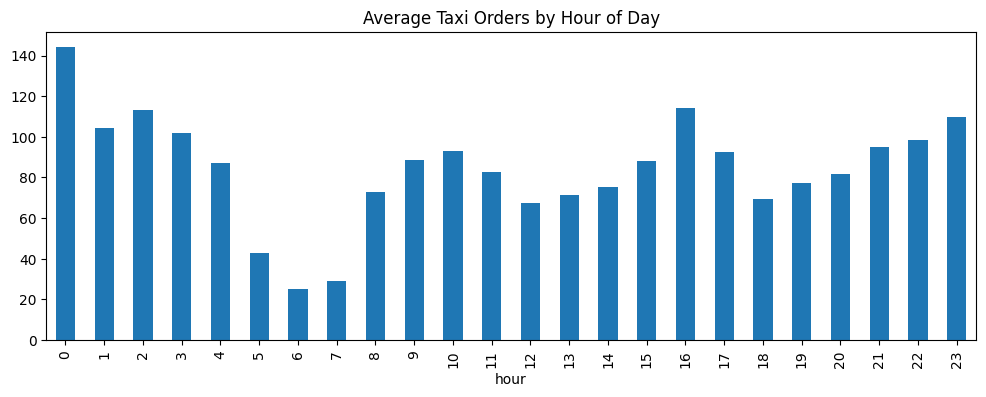

In [5]:
#Average hourly behavior -bars
df_hourly['hour'] = df_hourly.index.hour

hourly_profile = df_hourly.groupby('hour')['num_orders'].mean()

hourly_profile.plot(
    kind='bar',
    figsize=(12, 4),
    title='Average Taxi Orders by Hour of Day'
)

**Observations** This plot shows the daily demand pattern with 3 peaks in this case:
* Late night or very early morning from 00:00 to 02:00. Highest average demand. Likely driven by late flights and overnight arrivals.
* Morning peak from 08:00 to 10:00. Typical airport rush for business travelers.
* Afternoon and early evening peak from 15:00 to 17:00. Strong rise in demand. 

<Figure size 1400x500 with 0 Axes>

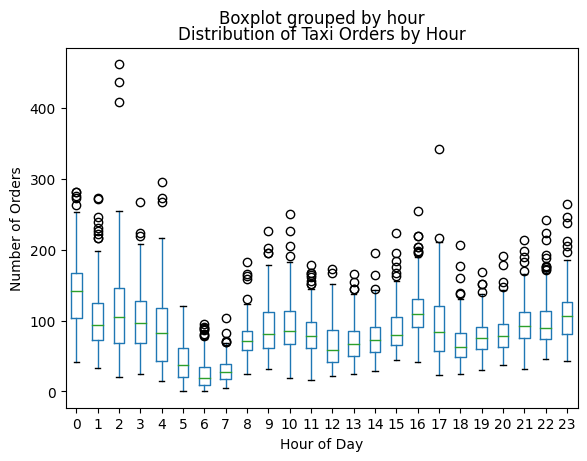

In [6]:
#hourly behavior - box
plt.figure(figsize=(14, 5))
df_hourly.boxplot(
    column='num_orders',
    by='hour',
    grid=False
)
plt.title('Distribution of Taxi Orders by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.show()

**Observations** Confirms the same three peaks. Shows higher variability during peak hours with wider boxes and more outliers.

Late night and afternoon peaks have: Higher medians and Larger spread. Which makes it harder to predict.

<AxesSubplot:title={'center':'Hourly Orders with 24-Hour Rolling Mean'}, xlabel='datetime'>

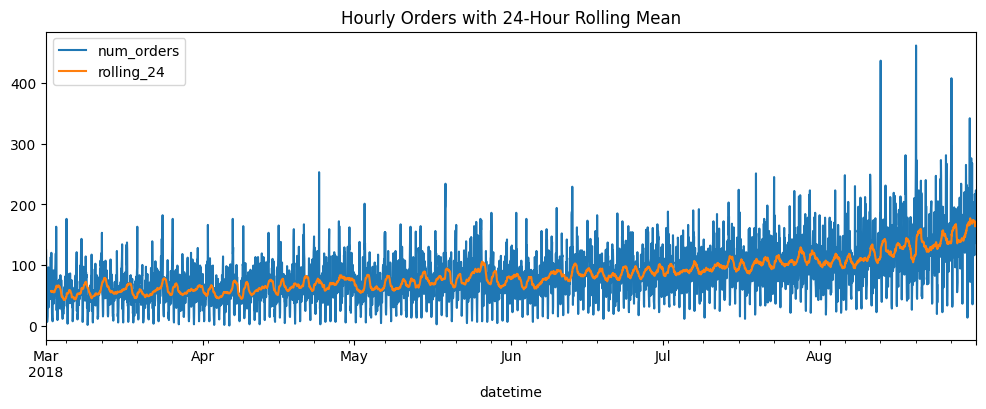

In [7]:
df_hourly['rolling_24'] = (
    df_hourly['num_orders']
    .shift(1)
    .rolling(24)
    .mean()
)

df_hourly[['num_orders', 'rolling_24']].plot(
    figsize=(12, 4),
    title='Hourly Orders with 24-Hour Rolling Mean'
)

**Observations**
The 24-hour rolling mean represents the average number of taxi orders over the previous 24 hours at each point in time. Instead of focusing on individual hourly spikes, this helps smooth out short-term fluctuations and highlights the overall daily trend in demand.

In the plot, the raw hourly data shows significant variability, while the rolling mean reveals a gradual increase in demand over time. This confirms the presence of both daily seasonality and a longer-term upward trend, which supports the use of rolling average features in the forecasting model.

## Training

In [8]:
train_size = int(len(df_hourly) * 0.9)

train = df_hourly[:train_size]
test = df_hourly[train_size:]

In [9]:
#Lag features

def make_features(data, lags, rolling_windows):
    df_feat = data.copy()

    # Lag features
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['num_orders'].shift(lag)

    # Rolling mean features
    for window in rolling_windows:
        df_feat[f'rolling_mean_{window}'] = (
            df_feat['num_orders'].shift(1).rolling(window).mean()
        )

    return df_feat

In [10]:
#features
lags = [1, 2, 3, 6, 12, 24]
rolling_windows = [3, 6, 12, 24]

df_features = make_features(df_hourly, lags, rolling_windows)
df_features = df_features.dropna()

**Observations**
* Lag 1: last hour
* Lag 24: same hour yesterday

Rolling means smooth noise and capture trends

In [11]:
#Split after features
train = df_features[:train_size]
test = df_features[train_size:]

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']


In [12]:
#Baseline Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_rmse

47.1035034031363

In [13]:
#Random forest
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_rmse

42.85187320178564

**Observations**

After correcting the rolling features to ensure that only past observations were used, the linear regression model achieved an RMSE of 47.1 on the test set, meeting the project requirement of RMSE ≤ 48.

A random forest model further improved performance, achieving an RMSE of 42.5, indicating that non-linear relationships also play a role in predicting taxi demand.

In [14]:
#Random forest with different hyperparameters
rf_tuned = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

rf_pred = rf_tuned.predict(X_test)
rft_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rft_rmse

42.63654027441404

**Observations**
Tuning the Random Forest hyperparameters did not result in a significant improvement in RMSE. This suggests that the model had already captured most of the predictive signal available from the engineered features, and further complexity did not lead to better generalization.

In [15]:
#Light GBM 
lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

lgbm_rmse

45.541196860783685

In [16]:
lgbm2 = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=50,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm2.fit(X_train, y_train)

lgbm2_pred = lgbm2.predict(X_test)
lgbm2_rmse = np.sqrt(mean_squared_error(y_test, lgbm2_pred))

lgbm2_rmse

45.75791002348406

**Observations** 

While LightGBM is a powerful gradient boosting model, it did not outperform the Random Forest in this case. This suggests that the engineered lag and rolling features already capture most of the relevant structure in the data, and additional boosting complexity does not significantly improve predictive performance.

In [17]:
#Further improvements
df_features['hour'] = df_features.index.hour
df_features['dayofweek'] = df_features.index.dayofweek
df_features['is_weekend'] = (df_features['dayofweek'] >= 5).astype(int)

In [18]:
#Same lightGMB2
train = df_features[:train_size]
test = df_features[train_size:]

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

lgbm2 = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=50,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm2.fit(X_train, y_train)

lgbm2_pred = lgbm2.predict(X_test)
new_lgbm2_rmse = np.sqrt(mean_squared_error(y_test, lgbm2_pred))

new_lgbm2_rmse

43.52668539054241

In [19]:
#results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Random Forest (tuned)', 'LightGBM','LightGBM (tuned)','LightGBM (tuned 2)'],
    'RMSE': [lr_rmse, rf_rmse, rft_rmse, lgbm_rmse, lgbm2_rmse, new_lgbm2_rmse]
})

results.sort_values('RMSE')


,Model,RMSE
2,Random Forest (tuned),42.636540
1,Random Forest,42.851873
5,LightGBM (tuned 2),43.526685
3,LightGBM,45.541197
4,LightGBM (tuned),45.757910
0,Linear Regression,47.103503


## Conclusion

Several models were trained and evaluated to predict the number of taxi orders for the next hour. All models were assessed using RMSE on a time-based test split.

* Linear Regression provided a strong baseline and met the project requirement with an RMSE of 47.1.
* Random Forest achieved the best overall performance, with an RMSE of approximately 42.6, indicating its ability to capture non-linear patterns in the data.
* LightGBM, including tuned versions and additional calendar features (hour, day of week, and weekend indicator), did not outperform Random Forest and resulted in an RMSE of around 43.52

Based on the evaluation results, Random Forest was selected as the final model due to its superior performance and robustness. It offers the best balance between accuracy and generalization for this forecasting task.

The model successfully captures daily demand patterns and peak hours, making it suitable for forecasting short-term taxi demand at airports. These predictions can help the company proactively allocate drivers during high-demand periods and improve service availability.